In [21]:
import numpy as np
import matplotlib.pyplot as plt

### Пусть $\xi_1, \xi_2,...$ - последовательность независимых случайных величин из хи-квадрат распределения с 3 степенями свободы.   
### Привести графическую иллюстрацию закона больших чисел.

Начнем с определений, что вообще такое хи-квадрат распределение с 3 степенями свободы?

**Определение** - $\chi^2$ распределение с $k \in \mathbb{N}$ степенями свободы - это распределение суммы квадратов $k$ независимых стандартных нормальных случайных величин, т.е. такого набора $\zeta_1, \zeta_2,... : \zeta_i \sim N(0,1) \ i \in \{1,2,...k\}$

Соответственно, функция распределения $\xi \sim \chi^2 = \sum{\zeta_i^2}, \ \zeta_i \sim N(0,1), \ i \in \{1,2,...,k\}$ - это   
$F_{\xi}(t) = \mathbb{P}(\xi \in (-\inf, t)) = \mathbb{P}(\xi < t)$

$\chi^2(k)$ распределение - это частный случай Гамма распределения, в частности: $\xi \sim \chi^2(k) \Longrightarrow \xi \sim Gamma(a=\frac{k}{2}, \theta = 2)$ 

С распределением вроде разобрались. Построим себе для наглядности графики функции распределения  
 и плотности для каждого $\zeta_i$

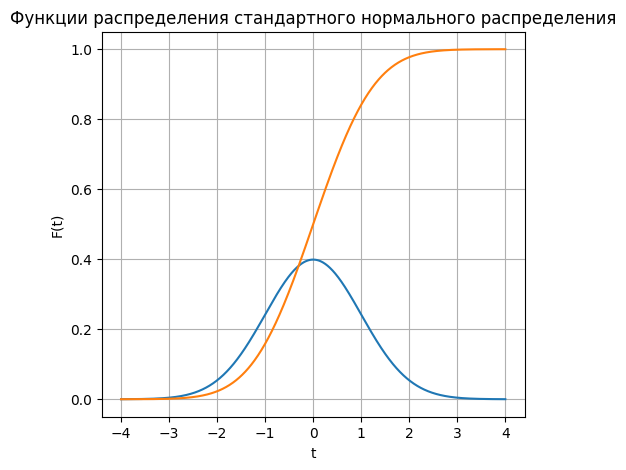

In [22]:
"""
Воспользуемся для этого библиотекой scipy
"""

from scipy.stats import norm

t = np.linspace(-4,4,1000)

pdf = norm.pdf(t)
cdf = norm.cdf(t)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t, pdf)
plt.title("Плотность стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("f(t)")

plt.subplot(1,2,1)
plt.plot(t, cdf)
plt.title("Функции распределения стандартного нормального распределения")
plt.xlabel("t")
plt.ylabel("F(t)")
plt.grid()

plt.show()

Нас просят привести графическую интерпретацию закона больших чисел. Давайте вспомним, что это такое!

Говорим, что последовательность случайных величин $\xi_1, \xi_2,...$ с конечными первыми моментами (т.е. $\mathbb{E}(\xi_i) < \infty , \ i \in \mathbb{N})$ удовлетворяет **закону больших чисел** **(ЗБЧ)**, если:   
$$\frac{\xi_1 + ... + \xi_n}{n} - \frac{\mathbb{E}(\xi_1)+...+\mathbb{E}(\xi_n)}{n} \xrightarrow{p} 0, \ n \rightarrow \infty \ \ (1)$$

Где последовательность случайных величин $\zeta_n \xrightarrow{p} 0 , \ n \rightarrow \infty \Longleftrightarrow$   
$\Longleftrightarrow \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n - 0| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty \equiv \forall \epsilon > 0 \ : \ \mathbb{P}(|\zeta_n| \geq \epsilon) \rightarrow 0 \ , \ n \rightarrow \infty$

Соответственно **законами больших чисел** принято называть утверждения о том, **при каких условиях** последовательность случайных величин удовлетворяет **закону больших чисел**, т.е. выполняется свойство (1)

По условию задачи мы работаем с последовательностью независимых и одинаково распределенных случайных величин, соответственно, можно воспользоваться **ЗБЧ Чебышёва**:     
$$ \frac{\xi_1 + ... + \xi_n}{n} \xrightarrow{p} \mathbb{E}(\xi_1) \ , n \rightarrow \infty \ \ \ (2)$$

Для его выполнения нам нужно требовать конечность первого момента $\xi_i$, поэтому давайте посчитаем его.

$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{E}(\xi) = \mathbb{E}(\sum_{i=1}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^2)} = \sum_{i=1}^{k=3}{1} = k = 3\Longrightarrow$$
$\Longrightarrow \mathbb{E}(\xi) = 3$

Аналогичными рассуждениями определим дисперсию $\xi_i$  
$\xi_i = \xi_1 = \xi \sim \chi^2(3) \Longrightarrow \xi = \zeta_1^2 + \zeta_2^2 + ... + \zeta_k^2, \ \zeta_i = \zeta \sim N(0,1) \Longrightarrow$  
$$\Longrightarrow \mathbb{D}(\xi) = \mathbb{D}(\sum_{i=0}^{k=3}{(\zeta_i^2)}) = \sum_{i=1}^{k=3}{\mathbb{D}(\zeta_i^2)} = \sum_{i=1}^{k=3}{\mathbb{E}(\zeta_i^4) - (\mathbb{E}(\zeta_i^2))^2} = \sum_{i=1}^{k=3}{3 - 1} = \sum_{i=1}^{k=3}{2} = 6  \Longrightarrow$$
$\Longrightarrow \mathbb{D}(\xi) = 6$

Соответственно, остается показать верность (2) при увеличении n. 

In [23]:
"""
Сгенерируем выборку, из которой будет состоять наша последовательность случайных величин
"""

N = 2000

xi = np.random.chisquare(df=3, size=N)

print(xi)

[1.47979796 1.16911019 1.41949616 ... 6.01519968 0.97493723 2.23628031]


In [24]:
"""
Найдем кумулятивную сумму (S_n) и вычислим выборочное среднее для каждого из n = 1, 2, ... , N
"""

S_n = np.cumsum(xi)

sample_mean = S_n / np.arange(1, N+1)

print(f"S_n = {S_n}, \n")

print(f"sample_mean = {sample_mean}, \n")

S_n = [1.47979796e+00 2.64890815e+00 4.06840430e+00 ... 6.01464341e+03
 6.01561835e+03 6.01785463e+03], 

sample_mean = [1.47979796 1.32445407 1.35613477 ... 3.01033204 3.00931383 3.00892731], 



In [25]:
"""
Заранее обернем это в функцию
"""

def sample(N):

    xi = np.random.chisquare(df=3, size=N)

    S_n = np.cumsum(xi)

    sample_mean = S_n / np.arange(1, N+1)

    return sample_mean

Зададим на графике вертикальную отсечку, равную той точке, в которой разница последней четверти выборочного среднего отличается от ответа не больше, чем стандартное отклоенение.

Чему же будет равно это отклонение? 

$\sigma(\frac{S_n}{n}) = \sqrt{\mathbb{D}(\frac{S_n}{n})} = \sqrt{\frac{6}{n}}$

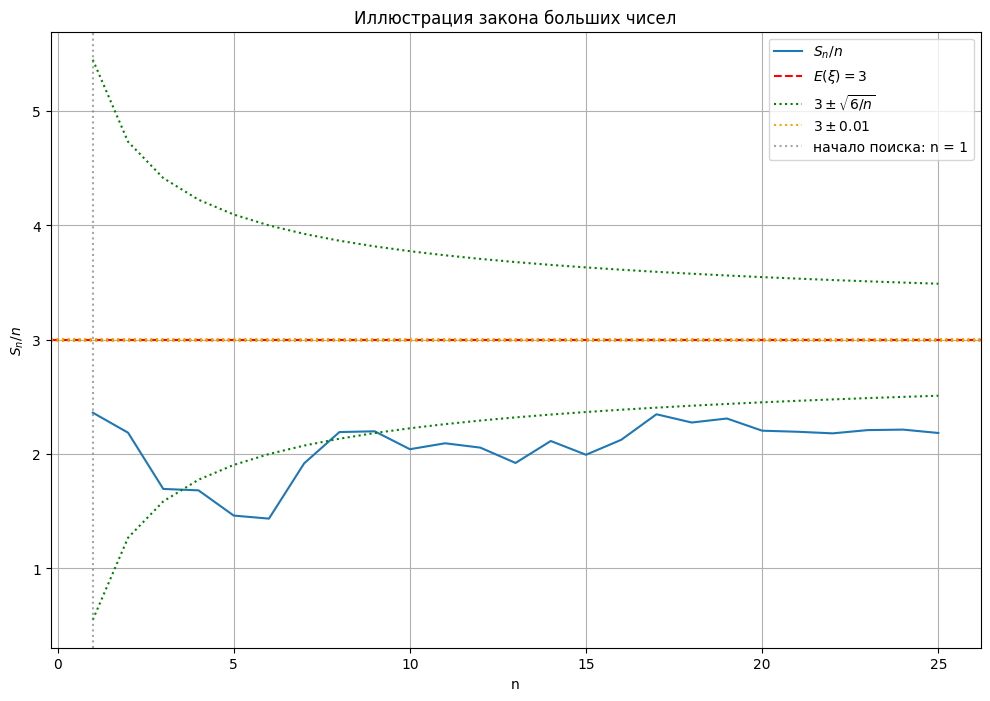

In [ ]:
def illustration(sample_mean):

    plt.figure(figsize=(12,8))

    plt.plot(sample_mean, label = "S_n/n")
    plt.axhline(3, linestyle="--", label="E(xi) = 3", color="red")

    plt.xlabel("n")
    plt.ylabel("S_n/n")
    plt.title("Иллюстрация закона больших чисел")

    plt.legend()
    plt.grid()

    plt.show()

illustration(sample(N=100))

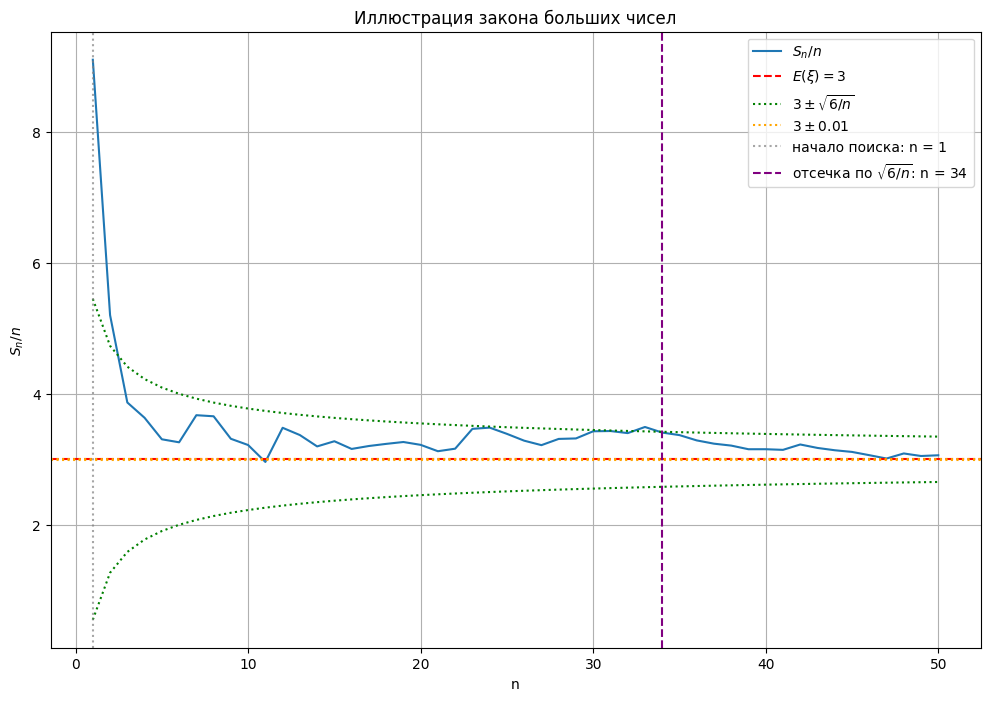

In [27]:
illustration(sample(N=50))

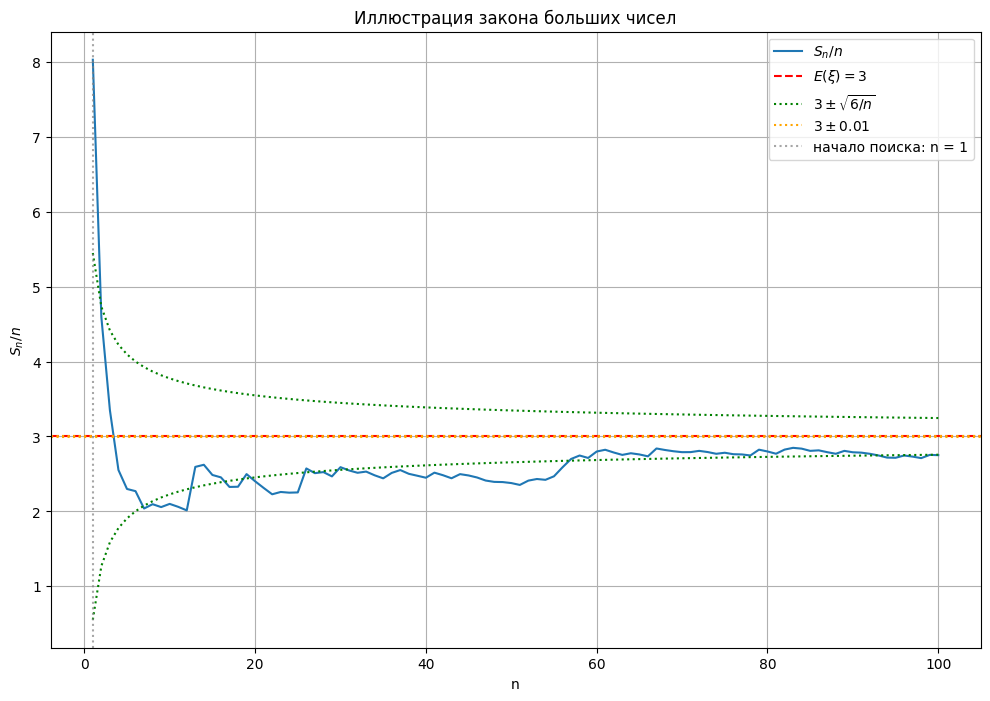

In [28]:
illustration(sample(N=100))

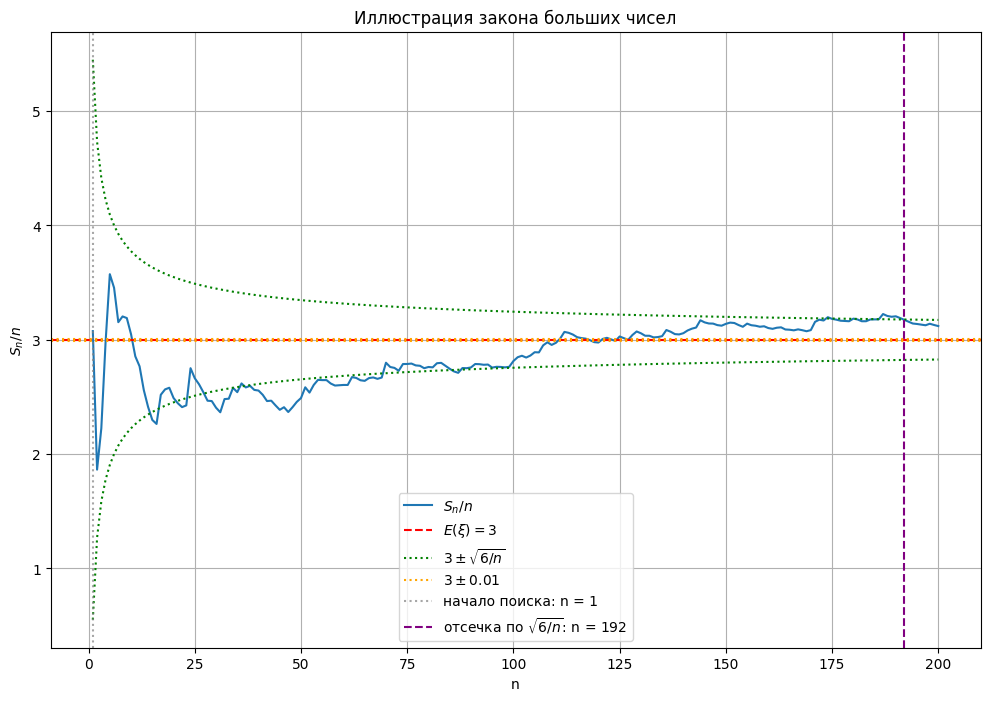

In [29]:
illustration(sample(N=200))

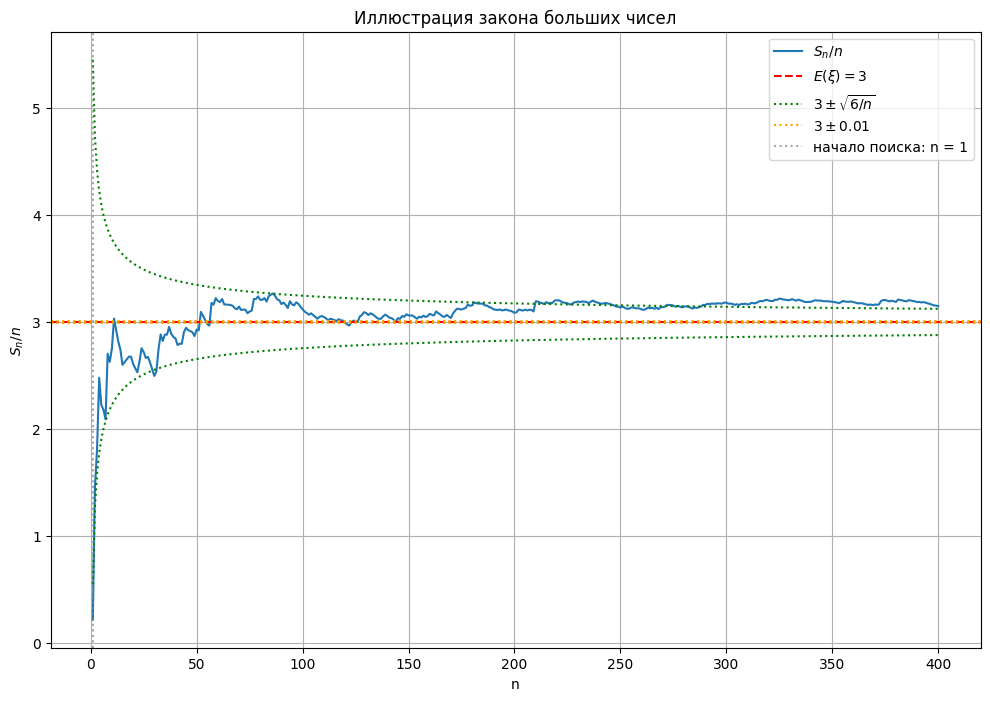

In [30]:
illustration(sample(N=400))

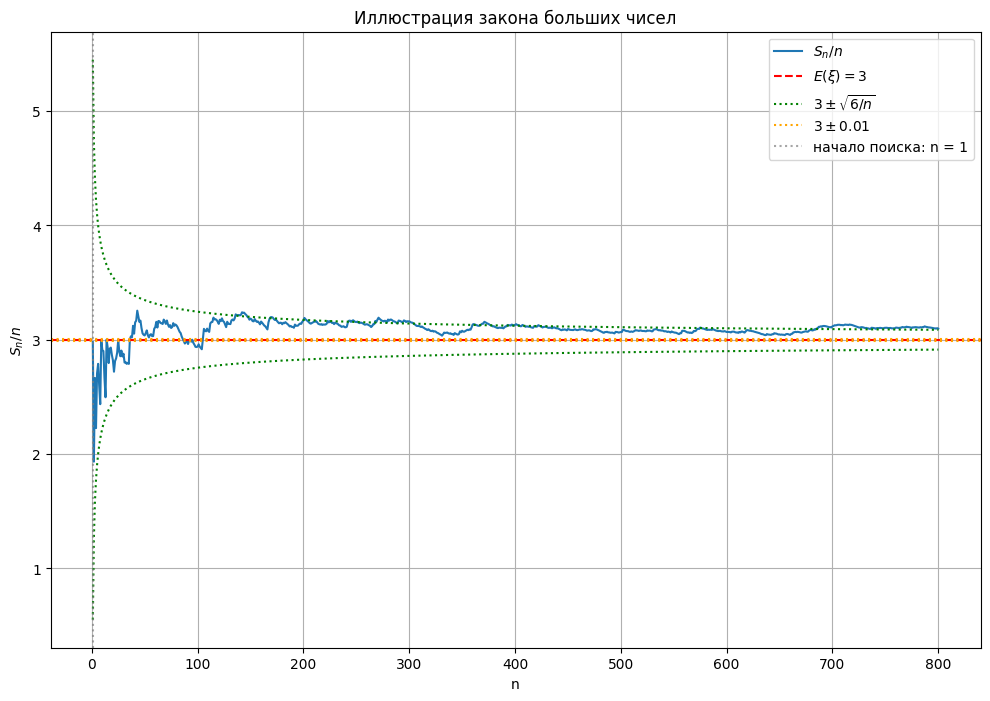

In [31]:
illustration(sample(N=800))

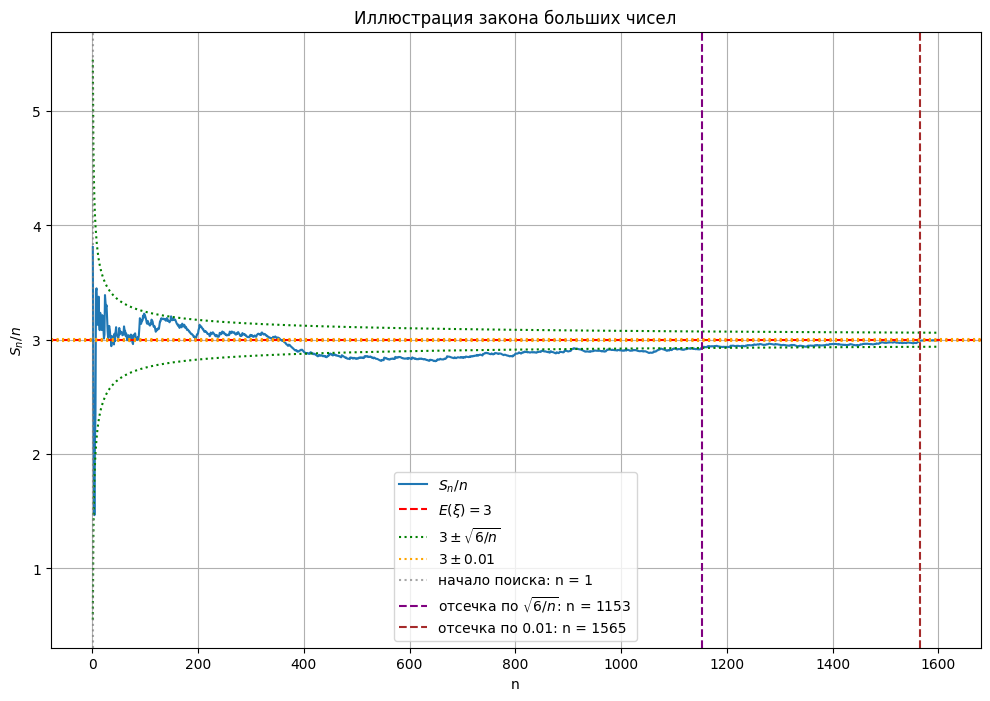

In [32]:
illustration(sample(N=1600))

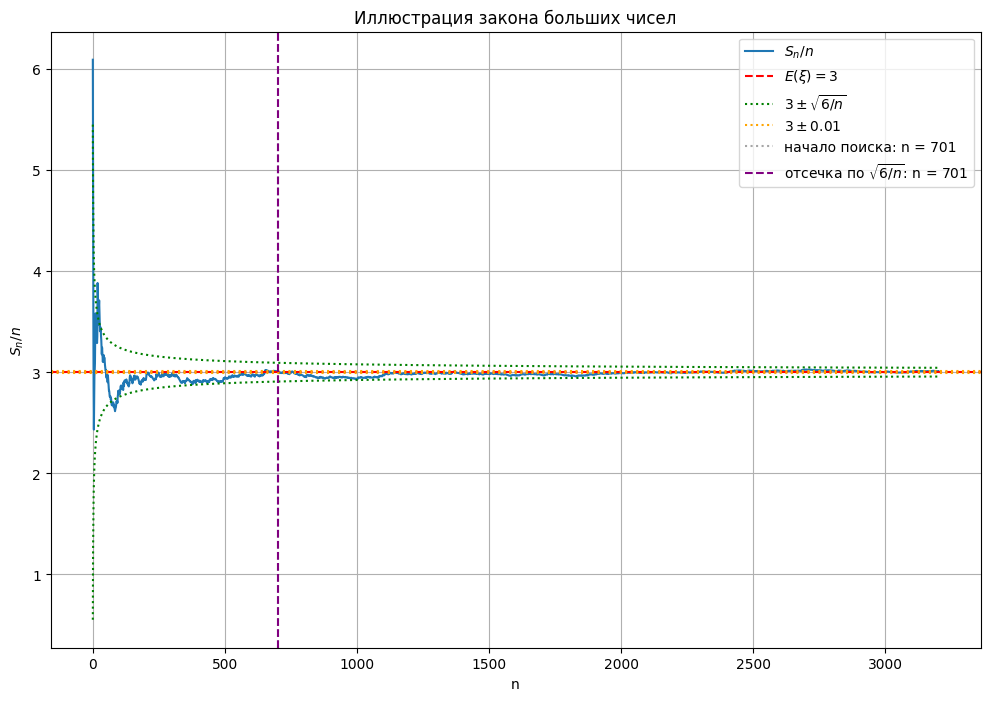

In [33]:
illustration(sample(N=3200))

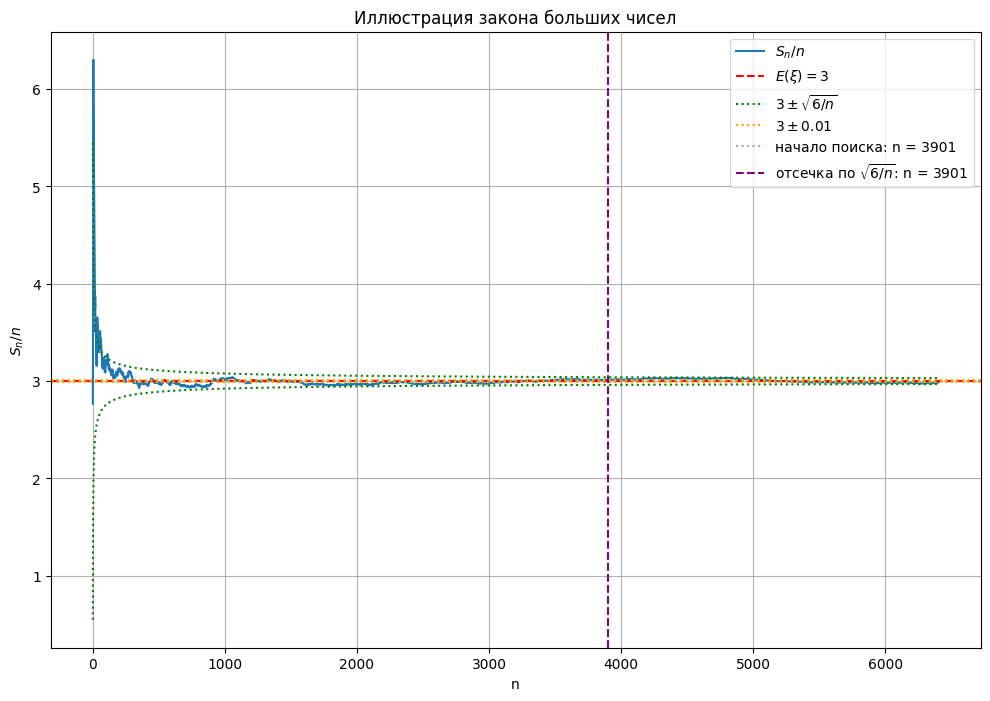

In [34]:
illustration(sample(N=6400))

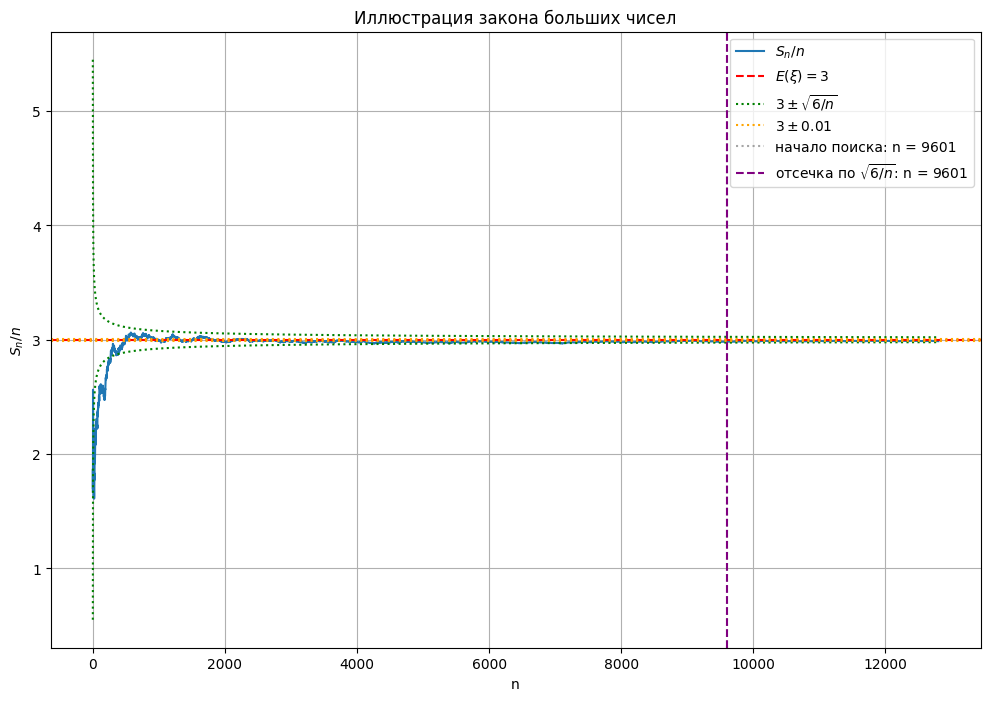

In [35]:
illustration(sample(N=12800))

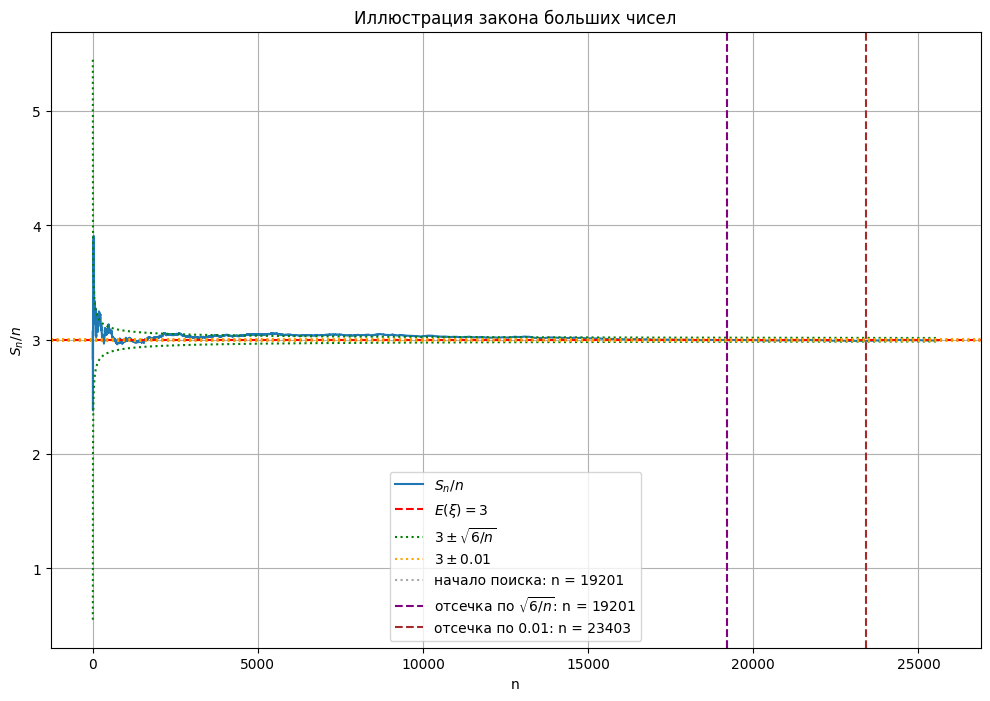

In [36]:
illustration(sample(N=25600))

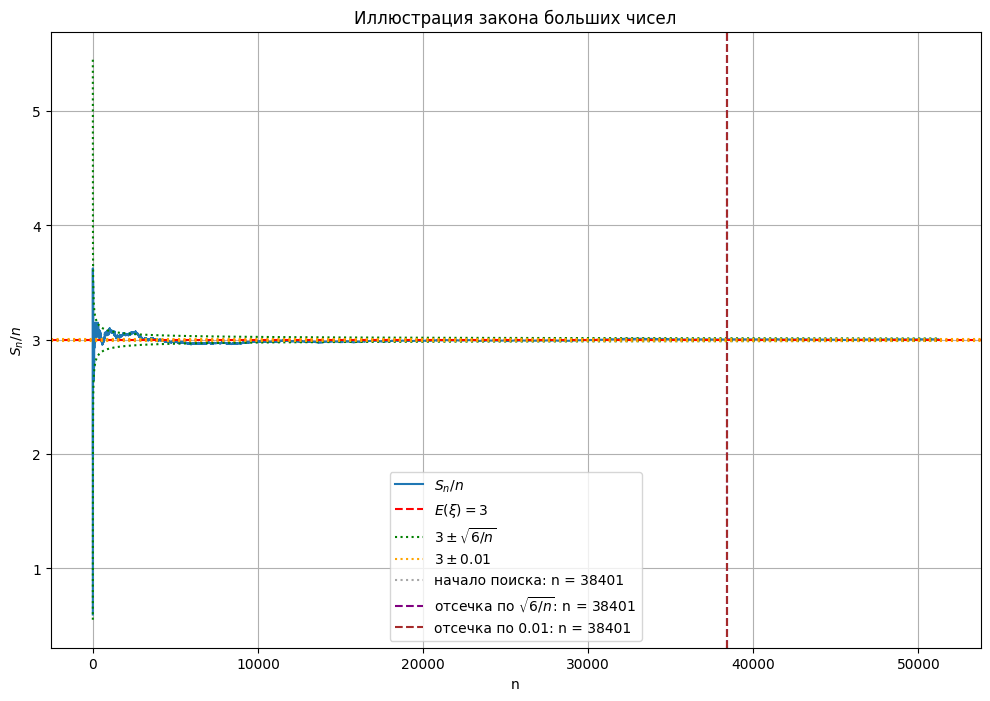

In [37]:
illustration(sample(N=51200))

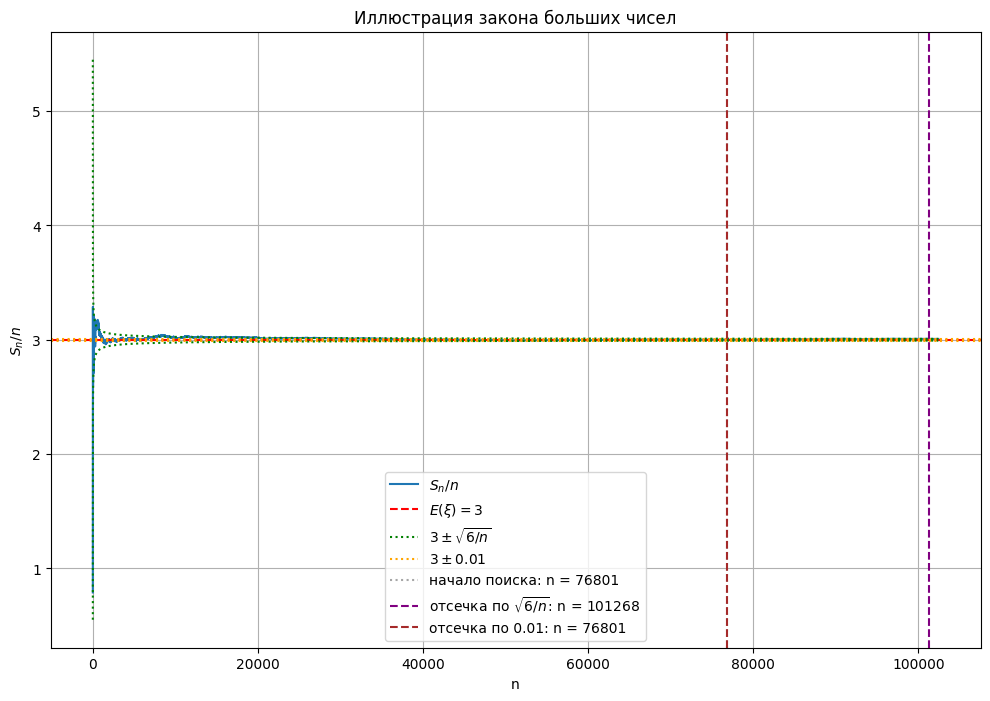

In [38]:
illustration(sample(N=102400))

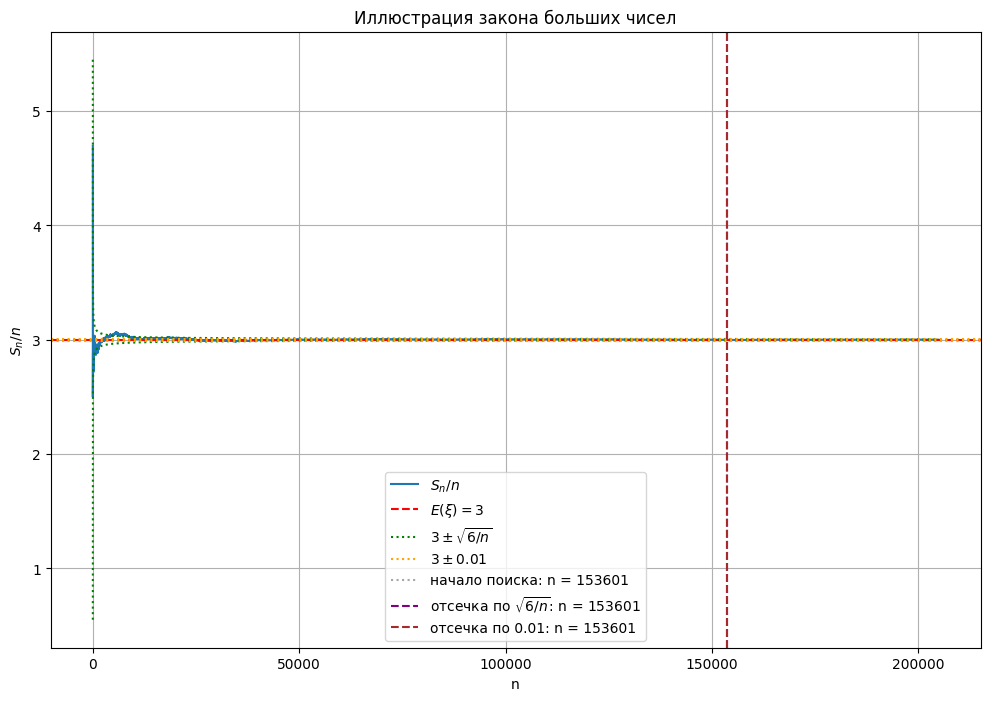

In [39]:
illustration(sample(N=204800))

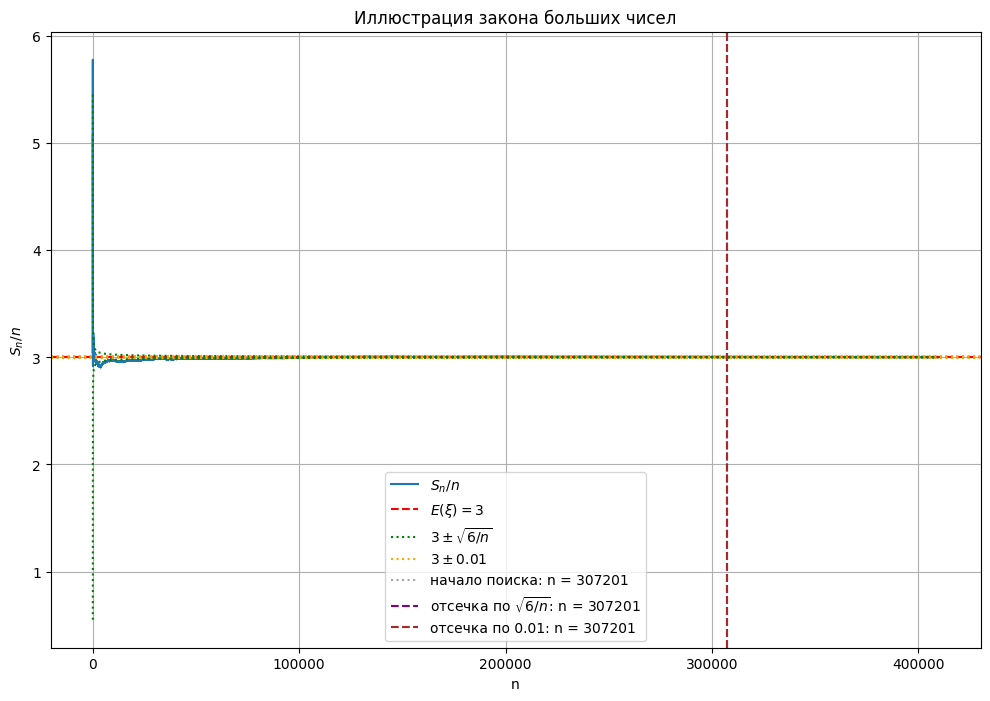

In [40]:
illustration(sample(N=409600))

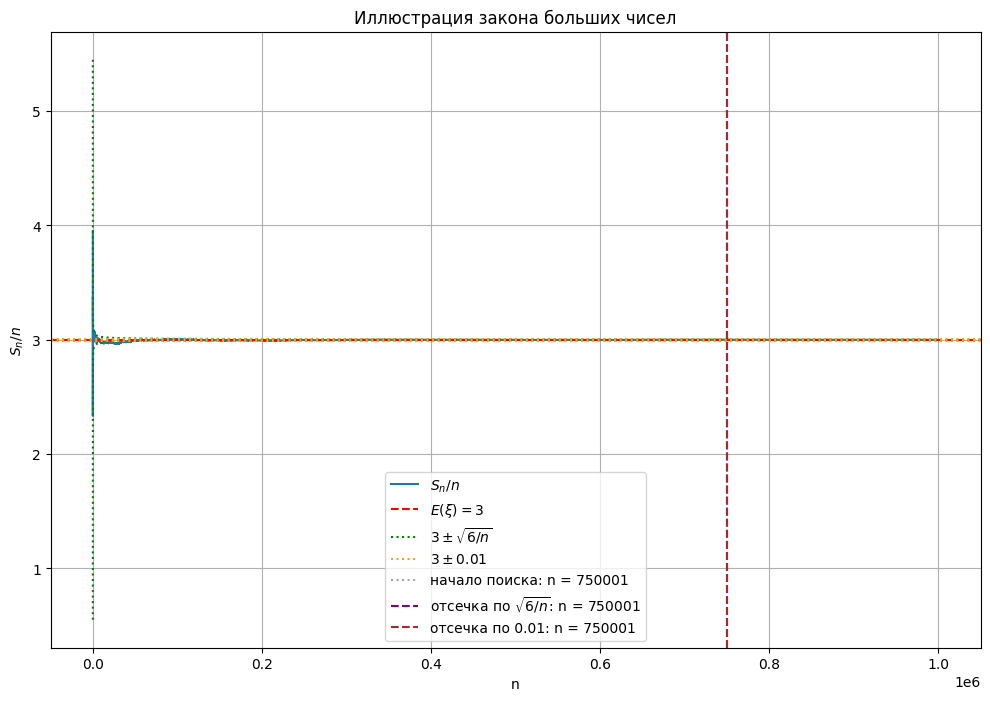

In [41]:
illustration(sample(N=1_000_000))

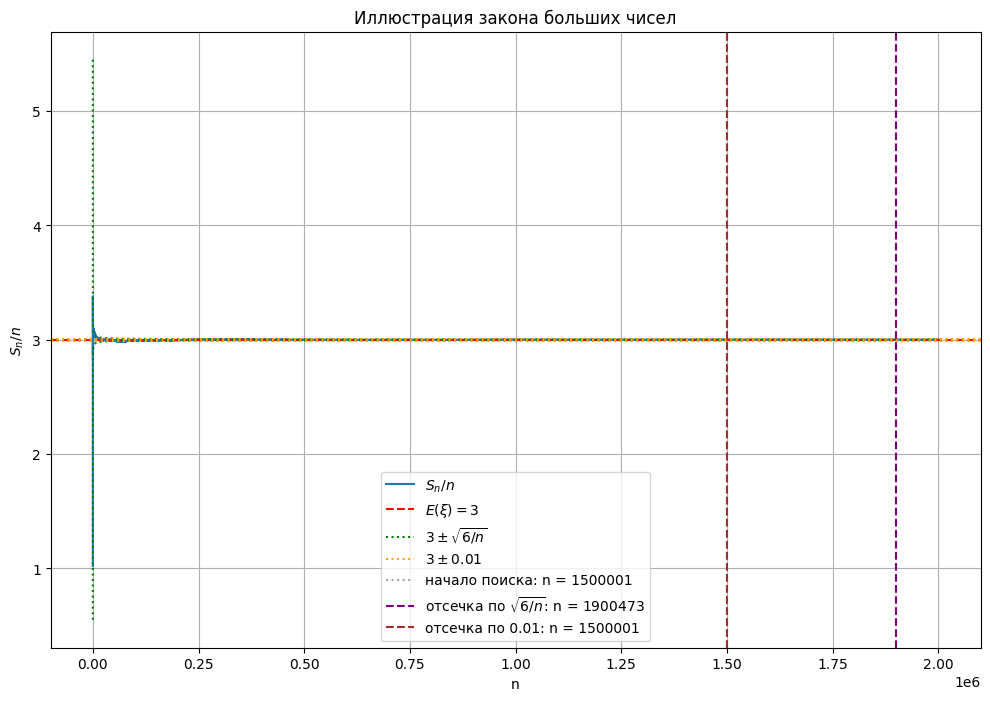

In [42]:
illustration(sample(N=2_000_000))